# PromptTemplate的使用

1、PromptTemplate如何获取实例  (掌握，两种方式)

2、两种特殊结构的使用 （部分提示词模板的使用(掌握)、组合提示词的使用）

3、给变量赋值的两种方式(掌握)：format() / invoke()

4、结合大模型的使用

## 1、PromptTemplate如何获取实例

方式1：使用构造方法的方式


In [4]:
from langchain_core.prompts import PromptTemplate

# 创建模板
prompt_template = PromptTemplate(
    template="你是一个{role},你的名字叫{name}",
    input_variables=["role", "name"]
)

print("===== PromptTemplate对象 =====")
print(type(prompt_template))

print("\n===== 模板内容 =====")
print(prompt_template.template)

print("\n===== 输入变量 =====")
print(prompt_template.input_variables)

# 填充变量
prompt = prompt_template.format(
    role="人工智能专家",
    name="小智"
)

print("\n===== format后 =====")
print(type(prompt))

print(prompt)

===== PromptTemplate对象 =====
<class 'langchain_core.PromptTemplate'>

===== 模板内容 =====
你是一个{role},你的名字叫{name}

===== 输入变量 =====
['role', 'name']

===== format后 =====
<class 'str'>
你是一个人工智能专家,你的名字叫小智


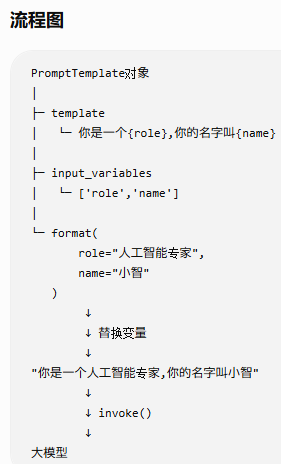

In [5]:
from langchain.prompts import PromptTemplate

#定义多变量模板
template = PromptTemplate(
    template="请评价{product}的优缺点，包括{aspect1}和{aspect2}。",
    input_variables=["product", "aspect1", "aspect2"])

#使用模板生成提示词
prompt_1 = template.format(product="智能手机", aspect1="电池续航", aspect2="拍照质量")
prompt_2 = template.format(product="笔记本电脑", aspect1="处理速度", aspect2="便携性")

print("提示词1:",prompt_1)
print("提示词2:",prompt_2)

提示词1: 请评价智能手机的优缺点，包括电池续航和拍照质量。
提示词2: 请评价笔记本电脑的优缺点，包括处理速度和便携性。


方式2：from_template() : 推荐！！

In [10]:
from langchain_core.prompts import PromptTemplate


#1、创建PromptTemplate的实例
prompt_template = PromptTemplate.from_template(template="你是一个{role},你的名字叫{name}")

# print(prompt_template)


#2、填充实例中的变量。暂且使用format()
prompt = prompt_template.format(role="人工智能专家",name="小智")

print(prompt)


你是一个人工智能专家,你的名字叫小智


In [17]:
from langchain.prompts import PromptTemplate

#定义多变量模板
template = PromptTemplate.from_template(template="请评价{product}的优缺点，包括{aspect1}和{aspect2}。")

#使用模板生成提示词
prompt_1 = template.format(product="智能手机", aspect1="电池续航", aspect2="拍照质量")

print(prompt_1)

请评价智能手机的优缺点，包括电池续航和拍照质量。


完整 LangChain + LLM 调用版：

In [ ]:
import os
import dotenv

from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

# 1. 加载环境变量
dotenv.load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")

# 2. 创建模型
llm = ChatOpenAI(
    model=os.getenv("OLLAMA_MODEL")
)

# 3. 定义多变量模板
template = PromptTemplate.from_template(
    "请评价{product}的优缺点，包括{aspect1}和{aspect2}。"
)

# 4. 使用模板生成提示词
prompt_1 = template.format(
    product="智能手机",
    aspect1="电池续航",
    aspect2="拍照质量"
)

print("===== 生成的 Prompt =====")
print(prompt_1)

# 5. 调用大模型
response = llm.invoke(prompt_1)

print("\n===== AI 回答 =====")
print(response.content)

===== 生成的 Prompt =====
请评价智能手机的优缺点，包括电池续航和拍照质量。

===== AI 回答 =====
智能手机的优点通常包括：便携性、多任务处理能力、广泛的应用程序选择和快速的网络访问。然而，其缺点则包括：电池续航问题（特别是在使用高带宽应用程序或相机时）；屏幕分辨率和显示质量较低；数据隐私和安全问题；以及用户界面和可使用性的不足。


如果提示词模板中不包含变量，则调用format()时，不需要传入参数！

In [28]:
#1.导入相关的包
from langchain_core.prompts import PromptTemplate

# 2.定义提示词模版对象
text = """
Tell me a joke
"""

prompt_template = PromptTemplate.from_template(text)
# 3.默认使用f-string进行格式化（返回格式好的字符串）
prompt = prompt_template.format()
print(prompt)


Tell me a joke



完整 LangChain + LLM 版

In [30]:
import os
import dotenv

from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

# 加载环境变量
dotenv.load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")

# 创建模型
llm = ChatOpenAI(
    model=os.getenv("OLLAMA_MODEL")
)

# 无变量模板
prompt_template = PromptTemplate.from_template(
    """
Tell me a joke.
    """
)

# 不需要参数
prompt = prompt_template.format()

print("===== Prompt =====")
print(prompt)

# 调用模型
response = llm.invoke(prompt)

print("\n===== AI回答 =====")
print(response.content)

===== Prompt =====

Tell me a joke.
    

===== AI回答 =====
Why was the math book sad? 
Because it had too many problems!


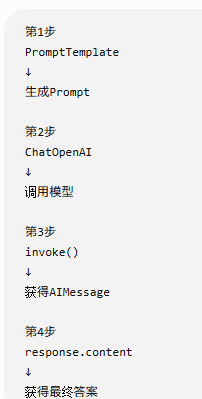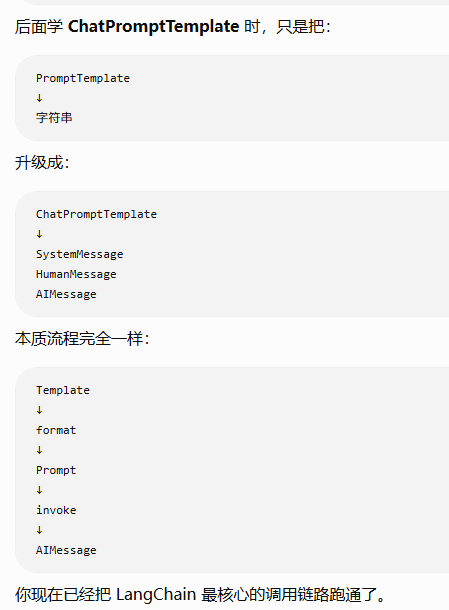

## 2、 两种特殊结构的使用 （部分提示词模板的使用、组合提示词的使用）

### 2.1 部分提示词模板的使用（重点）

方式1： 在PromptTemplate的构造方法或from_template()方法内，使用partial_variables设置


In [ ]:
from langchain.prompts import PromptTemplate

#定义多变量模板
template = PromptTemplate.from_template(
    template="请评价{product}的优缺点，包括{aspect1}和{aspect2}。", 
    partial_variables={"aspect1":"电池续航"}
)

#使用模板生成提示词
prompt_1 = template.format(product="智能手机",aspect2="拍照质量")

print(prompt_1)

请评价智能手机的优缺点，包括电池续航和拍照质量。


完整 LangChain + LLM 版

In [35]:
import os
import dotenv

from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")

llm = ChatOpenAI(
    model=os.getenv("OLLAMA_MODEL")
)

# 固定 aspect1
template = PromptTemplate.from_template(
    "请评价{product}的优缺点，包括{aspect1}和{aspect2}。",
    partial_variables={
        "aspect1":"电池续航"
    }
)

prompt = template.format(
    product="智能手机",
    aspect2="拍照质量"
)

print("===== Prompt =====")
print(prompt)

response = llm.invoke(prompt)

print("\n===== AI回答 =====")
print(response.content)

===== Prompt =====
请评价智能手机的优缺点，包括电池续航和拍照质量。

===== AI回答 =====
 smartphones的优缺点主要表现在用户体验、电池续航和拍照质量等方面。以下是一些方面的分析：

1. 用户体验： smartphones的用户体验主要体现在屏幕分辨率，触摸屏的灵敏度上。此外，手机的操作系统稳定性也是一个重要的方面，手机软件的服务质量也是用户体验的重要反映。

2. 电池续航：智能手机的电池续航主要取决于电池的容量和使用方式。例如，使用手机多应用可能会消耗较多的电量，需要定期更换或更换电池。此外，手机的使用习惯和网络速度也会影响电池续航。

3. 拍照质量：智能手机的拍照质量主要体现在分辨率、像素大小上。手机的摄像头是手机拍照质量的重要组成部分，其分辨率和像素大小直接影响到拍照的细节和图像的清晰度。此外，手机的内置相机质量和后期编辑软件的质量也会影响拍照效果。

总的来说，智能手机的优缺点相互影响，不同的用户有不同的需求，不同的手机品牌和型号也会有不同的优缺点。


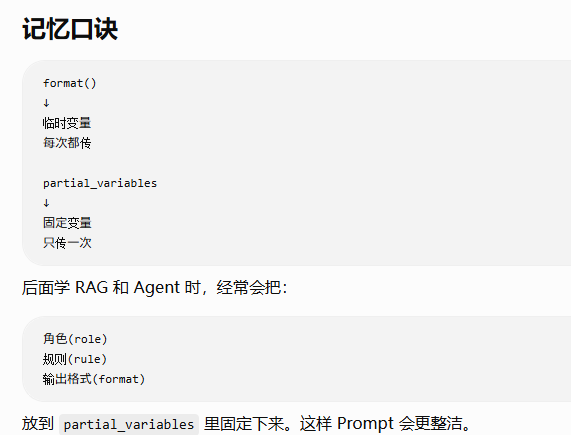

In [36]:
from langchain.prompts import PromptTemplate

#定义多变量模板
template = PromptTemplate(
    template="请评价{product}的优缺点，包括{aspect1}和{aspect2}。",
    input_variables=["product", "aspect1", "aspect2"],
    partial_variables={"aspect1":"电池续航","aspect2":"拍照质量"}
)

#使用模板生成提示词
prompt_1 = template.format(product="智能手机")

print("提示词1:",prompt_1)

提示词1: 请评价智能手机的优缺点，包括电池续航和拍照质量。


In [40]:
from langchain_core.prompts import PromptTemplate

template = PromptTemplate.from_template(
    "请评价{product}的优缺点，包括{aspect1}和{aspect2}。",
    partial_variables={
        "aspect1":"电池续航",
        "aspect2":"拍照质量"
    }
)

print(template.input_variables)
# ['product']

[]


In [41]:
from langchain_core.prompts import PromptTemplate

template = PromptTemplate.from_template(
    "请评价{product}的优缺点，包括{aspect1}和{aspect2}。",
    partial_variables={
        "aspect1":"电池续航",
        "aspect2":"拍照质量"
    }
)

print("input_variables:")
print(template.input_variables)

print("\npartial_variables:")
print(template.partial_variables)

print("\n测试不传product:")
try:
    print(template.format())
except Exception as e:
    print("报错:", e)

print("\n测试传product:")
print(
    template.format(
        product="智能手机"
    )
)

input_variables:
[]

partial_variables:
{'aspect1': '电池续航', 'aspect2': '拍照质量'}

测试不传product:
报错: 'product'

测试传product:
请评价智能手机的优缺点，包括电池续航和拍照质量。


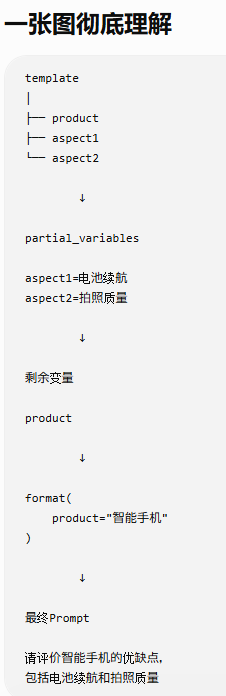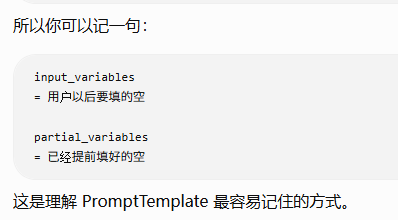

方式2：调用方法partial()  运行过程中再固定变量

In [42]:
from langchain.prompts import PromptTemplate

#定义多变量模板
template = PromptTemplate(
    template="请评价{product}的优缺点，包括{aspect1}和{aspect2}。",
    input_variables=["product", "aspect1", "aspect2"],
    # partial_variables={"aspect1":"电池续航","aspect2":"拍照质量"}
)

# partial()调用完以后，不会对调用者这个模板对象产生影响；而其返回值是一个新的模板
template1 = template.partial(aspect1="电池续航",aspect2="拍照质量")

#使用模板生成提示词
prompt_1 = template1.format(product="智能手机")

print("提示词1:",prompt_1)

提示词1: 请评价智能手机的优缺点，包括电池续航和拍照质量。


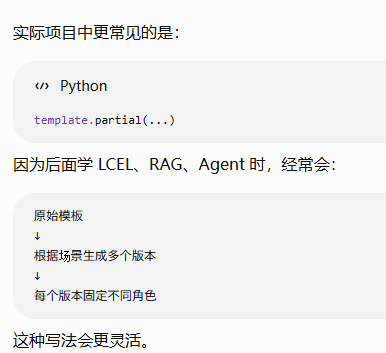

In [43]:
from langchain.prompts import PromptTemplate

#定义多变量模板
template = PromptTemplate(
    template="请评价{product}的优缺点，包括{aspect1}和{aspect2}。",
    input_variables=["product", "aspect1", "aspect2"],
).partial(aspect1="电池续航",aspect2="拍照质量")

#使用模板生成提示词
prompt_1 = template.format(product="智能手机")

print("提示词1:",prompt_1)

提示词1: 请评价智能手机的优缺点，包括电池续航和拍照质量。


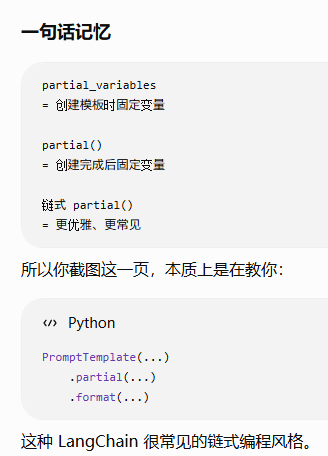

In [44]:
from langchain.prompts import PromptTemplate

#定义多变量模板
template = (PromptTemplate
            .from_template(template="请评价{product}的优缺点，包括{aspect1}和{aspect2}。")
            .partial(aspect1="电池续航",aspect2="拍照质量"))

#使用模板生成提示词
prompt_1 = template.format(product="智能手机")

print("提示词1:",prompt_1)

提示词1: 请评价智能手机的优缺点，包括电池续航和拍照质量。


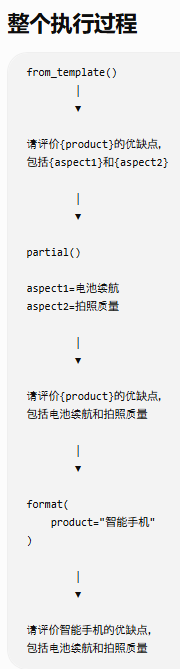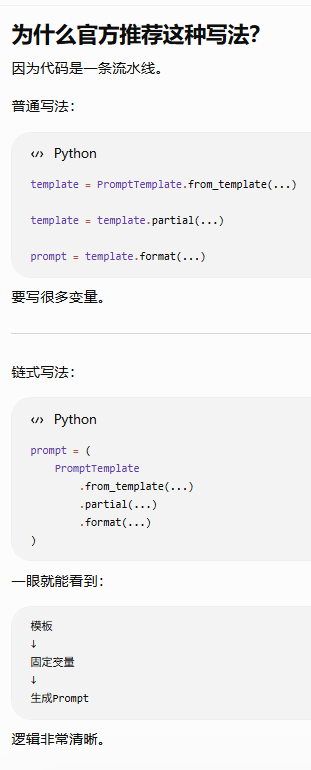

### 2.2 组合提示词的使用（了解）



In [47]:
from langchain_core.prompts import PromptTemplate

template = (
    PromptTemplate.from_template(template = "Tell me a joke about {topic}")
    + ", make it funny"
    + "\n\nand in {language}"
)

prompt = template.format(topic="sports", language="spanish")
print(prompt)

Tell me a joke about sports, make it funny

and in spanish


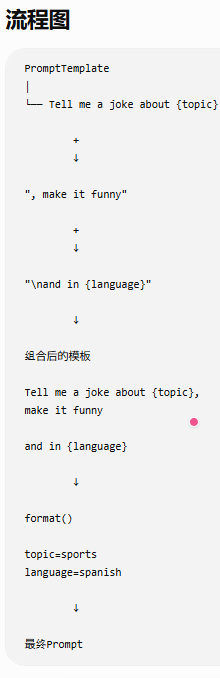

In [ ]:
import os
import dotenv

from langchain_core.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

dotenv.load_dotenv()

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")

llm = ChatOpenAI(
    model=os.getenv("OLLAMA_MODEL")
)
# 1. 定义多变量模板
template = (
    PromptTemplate.from_template(
        "Tell me a joke about {topic}"
    )
    + ", make it funny"
    + "\nand in {language}"
)
# 2. 使用模板生成提示词
prompt = template.format(
    topic="sports",
    language="Chinese"
)

print("===== Prompt =====")
print(prompt)
# 3. 调用大模型
response = llm.invoke(prompt)

print("\n===== AI回答 =====")
print(response.content)

===== Prompt =====
Tell me a joke about sports, make it funny
and in Chinese

===== AI回答 =====
当然可以！Here's a funny sports joke in Chinese:

"为什么足球运动员总是很勇敢？因为他们对进球非常有信心！"

这个笑话用通俗易懂的语言，表达了足球运动员对比赛胜利的信心和决心。希望你喜欢！


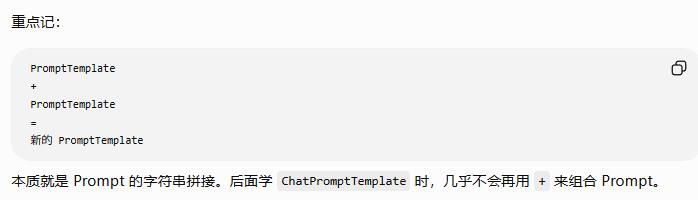

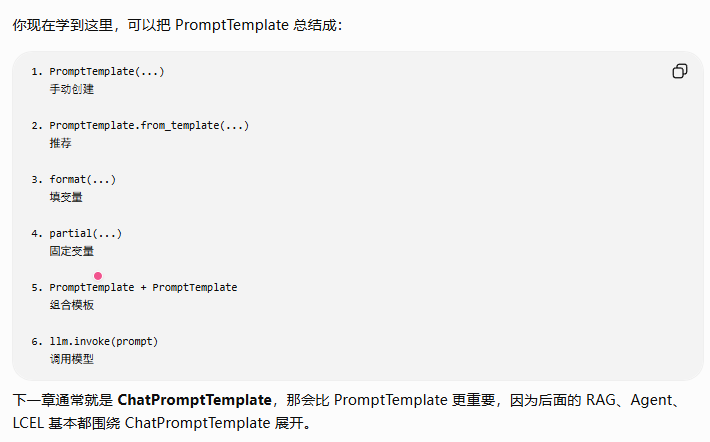

## 3、给变量赋值的两种方式：format() / invoke()

format() : 参数部分：给变量赋值;     返回值：str类型

invoke() : 参数部分：使用的是字典;     返回值：PromptValue类型   ---推荐！


举例：调用format()

In [50]:
from langchain.prompts import PromptTemplate

#定义多变量模板
template = PromptTemplate.from_template(
    template="请评价{product}的优缺点，包括{aspect1}和{aspect2}。")

#使用模板生成提示词
prompt_1 = template.format(product="智能手机", aspect1="电池续航", aspect2="拍照质量")

print(prompt_1)
print(type(prompt_1))

请评价智能手机的优缺点，包括电池续航和拍照质量。
<class 'str'>


举例：调用invoke() （推荐）

In [51]:
from langchain.prompts import PromptTemplate

#定义多变量模板
template = PromptTemplate.from_template(
    template="请评价{product}的优缺点，包括{aspect1}和{aspect2}。")

#使用模板生成提示词
# prompt_1 = template.format(product="智能手机", aspect1="电池续航", aspect2="拍照质量")
prompt_1 = template.invoke(input={"product":"智能手机","aspect1":"电池续航","aspect2":"拍照质量"})

print(prompt_1)
print(type(prompt_1))  #返回值类型：PromptValue

请评价智能手机的优缺点，包括电池续航和拍照质量。
<class 'langchain_core.StringPromptValue'>


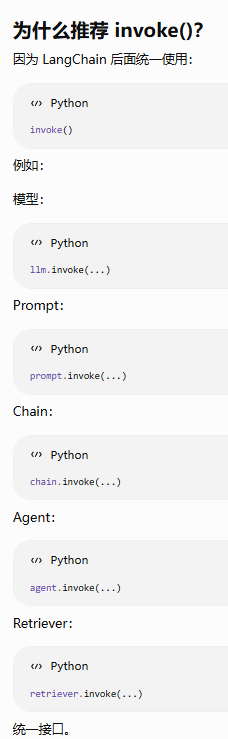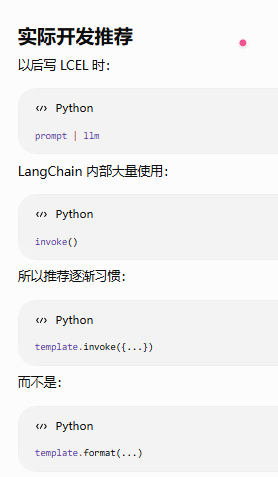

In [53]:
from langchain_core.prompts import PromptTemplate

template = PromptTemplate.from_template(
    "你好，我是{name}"
)

# format
result1 = template.format(
    name="小智"
)

print("format结果:")
print(result1)
print(type(result1))

print("\n=================\n")

# invoke
result2 = template.invoke({
    "name":"小智"
})

print("invoke结果:")
print(result2)
print(type(result2))

print("\n真实内容:")
print(result2.text)

format结果:
你好，我是小智
<class 'str'>


invoke结果:
你好，我是小智
<class 'langchain_core.StringPromptValue'>

真实内容:
你好，我是小智


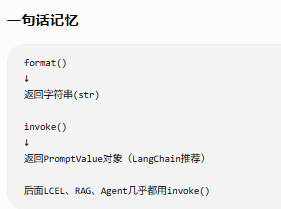

## 4、结合大模型的使用


In [57]:
from langchain_openai import ChatOpenAI
import os
import dotenv

#加载配置文件
dotenv.load_dotenv()


os.environ["OPENAI_BASE_URL"] = os.getenv("OPENAI_BASE_URL")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY1")


# 获取对话模型：
chat_model = ChatOpenAI(
    model="qwen2.5-coder:1.5b",
    max_tokens=500
)


# 生成提示词模板
template = PromptTemplate.from_template(
    template="请评价{product}的优缺点，包括{aspect1}和{aspect2}。")

# 给模板的变量赋值
prompt = template.invoke(input={"product":"智能手机","aspect1":"电池续航","aspect2":"拍照质量"})

# 调用大模型，将提示词传入
response= chat_model.invoke(prompt)
print(response)
print(type(response))

AIMessage(content='智能手机的优点包括屏幕大、界面简洁，操作方便，可以快速访问各种信息和应用程序。这些优点使得智能手机成为许多用户的主要上网工具。\n\n智能手机的缺点包括电池续航时间较短，需要频繁充电，这会增加用户的使用成本。此外，智能手机的性能也受到电池续航时间的影响，长时间使用可能会导致屏幕发热、电池耗尽等问题。\n\n在拍照质量方面，智能手机通常具有较好的拍照功能，可以拍摄高质量的照片。然而，也存在一些缺点，如分辨率较低，无法拍摄高动态范围照片，不能长时间连续拍照，难以捕捉到动作瞬间等。此外，拍照质量也受到电池续航时间的影响，长时间使用可能会导致电池耗尽，影响拍照效果。', additional_kwargs={})
<class 'langchain_core.AIMessage'>


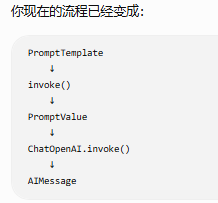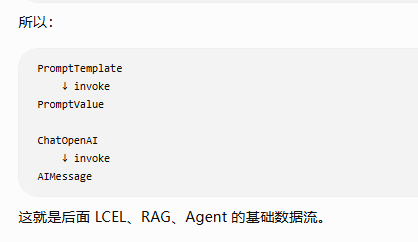

In [59]:
prompt = template.invoke({
    "product":"智能手机",
    "aspect1":"电池续航",
    "aspect2":"拍照质量"
})

print("===== Prompt对象 =====")
print(prompt)

print("\n===== Prompt文本 =====")
print(prompt.text)

response = chat_model.invoke(prompt)

print("\n===== AIMessage对象 =====")
print(response)

print("\n===== AI回答 =====")
print(response.content)

===== Prompt对象 =====
请评价智能手机的优缺点，包括电池续航和拍照质量。

===== Prompt文本 =====
请评价智能手机的优缺点，包括电池续航和拍照质量。

===== AIMessage对象 =====
AIMessage(content='智能手机的优点包括：\n1. 信息娱乐：智能手机是一款功能强大的手机，可以用来浏览网页、听音乐、下载应用程序、拍摄照片和视频。\n2. 数据传输和存储：智能手机可以用来分享文件、接收消息、观看直播和其他社交活动，也有能力存储大量数据。\n3. 高精度导航：智能手机可以用来导航路线、设置闹钟并查看天气预报等。\n4. 应用程序更新：智能手机经常更新应用程序，以提供新的功能和便利。\n\n智能手机的缺点包括：\n1. 电池续航时间：由于智能手机的功能繁多，电池续航时间可能会比较短。例如，一部手机可能仅能使用几小时，而另一部手机可能使用几天。\n2. 拍照质量：智能手机的拍照质量可能不如一些专业相机。例如，智能手机的自动模式可能不够精细，拍照的背景可能会过于模糊。', additional_kwargs={})

===== AI回答 =====
智能手机的优点包括：
1. 信息娱乐：智能手机是一款功能强大的手机，可以用来浏览网页、听音乐、下载应用程序、拍摄照片和视频。
2. 数据传输和存储：智能手机可以用来分享文件、接收消息、观看直播和其他社交活动，也有能力存储大量数据。
3. 高精度导航：智能手机可以用来导航路线、设置闹钟并查看天气预报等。
4. 应用程序更新：智能手机经常更新应用程序，以提供新的功能和便利。

智能手机的缺点包括：
1. 电池续航时间：由于智能手机的功能繁多，电池续航时间可能会比较短。例如，一部手机可能仅能使用几小时，而另一部手机可能使用几天。
2. 拍照质量：智能手机的拍照质量可能不如一些专业相机。例如，智能手机的自动模式可能不够精细，拍照的背景可能会过于模糊。


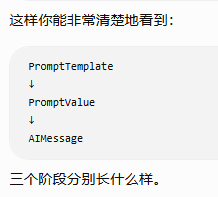